In [1]:
import pandas as pd
import os,re
import numpy as np
import seaborn as sns
from scipy.signal import find_peaks
import matplotlib.pyplot as plt

In [2]:
species='mouse' # 'human' or 'mouse'
# species='human' # 'human' or 'mouse'
if species[0].lower() == 'h':
    df=pd.read_csv("data/XI_DATA_HUMAN.csv",header=0,index_col=0,na_filter=True)
    n_tot=156040895
elif species[0].lower() == 'm':
    df=pd.read_csv("data/XI_DATA_MOUSE_Backup.csv",header=0,index_col=None,na_filter=True)
    n_tot=169476592
chrom_str=pd.read_csv('data/traj_smooth.dat',header=None).values
#----------------------------------
str_len=len(chrom_str)
#----------------------------------'
xic_begin=(df[(df['genes']=='Xist')|(df['genes']=='XIST')].values[0][1]/n_tot)*str_len
xic_end=(df[(df['genes']=='Xist')|(df['genes']=='XIST')].values[0][2]/n_tot)*str_len
print(f'XIC range for {species} and {str_len} points:',round(xic_begin),'to',round(xic_end))

XIC range for mouse and 20000 points: 12097 to 12099


## Checking match between simulation and experiment

### All

In [3]:
xi_state=np.zeros(str_len)
df=pd.read_csv("data/XI_DATA_MOUSE_Backup.csv",header=0,index_col=None,na_filter=True)
p_c=0.1
for i in df.index:
    p=round(df['expression_probability'][i],1)
    if p > p_c:
        i_start=int((int(df['Location_start'][i])/(n_tot))*str_len)
        i_end=int((int(df['Location_end'][i])/(n_tot))*str_len)+1
        xi_state[i_start:i_end]=1
        # break

In [6]:
def perform_data_analysis(time,t_wri,critical_ratio,run_id):
    if run_id>0:
        file_path=f'data/multi_run_mouse/run_{"%02d" % run_id}/fort.{200+int(time/t_wri)}'
    if run_id==-1:
        file_path=f'data/imposed_teth_mouse//fort.{200+int(time/t_wri)}'
    if run_id==0:
        file_path=f'data/dynamic_structure/fort.{200+int(time/t_wri)}'
    sim_result=pd.read_csv(file_path,sep='\s+',header=None).iloc[:,3]
    tube_points=min(sim_result.value_counts())
    sim_result_20k=sim_result.values[::tube_points]
    sim_result_20k=np.insert(sim_result_20k,0,sim_result_20k[0])
    sim_result_20k=np.insert(sim_result_20k,-1,sim_result_20k[-1]*np.ones(2))
    #-----------------
    sim_result_binary=np.ones(20000)
    for i in range(20000):
        if sim_result_20k[i] <1:
            sim_result_binary[i]=1
        else:
            sim_result_binary[i]=0
    percent=(round(((20000-np.sum(sim_result_binary))/20000)*100,2))
    #-----------------
    s='genes,start,stop,state_exp,state_sim\n'
    for gene,start,stop in zip(df['genes'],df['Location_start'],df['Location_end']):
        start_20k=int((start/n_tot)*20000)
        stop_20k=int((stop/n_tot)*20000)
        if start_20k==stop_20k : stop_20k+=1
        if (np.sum(xi_state[start_20k:stop_20k])/(stop_20k-start_20k))>=critical_ratio:
            state_exp=1
        else:
            state_exp=0
        if (np.sum(sim_result_binary[start_20k:stop_20k])/(1+stop_20k-start_20k))>=critical_ratio:
            state_sim=1
        else:
            state_sim=0
        s+=f"{gene},{start_20k},{stop_20k},{state_exp},{state_sim}\n"
    print(s,file=(open('expression_data_exp_sim.csv','w')))        
    return sim_result_20k,percent

### Run ID = 0 for Dynamic Structure || -1 for Imposed Thethering

In [7]:
s='Run_ID,Escapee_Count,Percent_Inactive'
critical_ratio=0.5
for id in list(range(1,21))+[0,-1]:
    sim_result_20k,percent_inactive=perform_data_analysis(time=500,t_wri=25,critical_ratio=critical_ratio,run_id=id)
    df_data_ana=pd.read_csv("expression_data_exp_sim.csv",header=0)
    n_escapee=df_data_ana[(df_data_ana['state_exp']==1)&(df_data_ana['state_sim']==1)].shape[0]
    s+=f'\n{id},{n_escapee},{percent_inactive}'
print(s,file=(open('multirun_data.csv','w')))

In [8]:
df_111=pd.read_csv('expression_data_exp_sim.csv')
n_esc_exp=df_111[df_111['state_exp']==1].shape[0]
print(f'The experimentally reported number of escapee genes: {n_esc_exp}')

The experimentally reported number of escapee genes: 38


### Ovary

In [9]:
def perform_data_analysis(time,t_wri,critical_ratio,run_id):
    df=pd.read_csv("data/inactivated_genes_ovary.csv",header=0,index_col=None,na_filter=True)
    df=df[['Gene','polymer_seg']]
    #--------------------------------------------
    if run_id>0:
        file_path=f'data/multi_run_mouse/run_{"%02d" % run_id}/fort.{200+int(time/t_wri)}'
    else:
        file_path=f'data/imposed_teth_mouse/fort.{200+int(time/t_wri)}'
    sim_result=pd.read_csv(file_path,sep='\s+',header=None).iloc[:,3]
    tube_points=min(sim_result.value_counts())
    sim_result_20k=sim_result.values[::tube_points]
    sim_result_20k=np.insert(sim_result_20k,0,sim_result_20k[0])
    sim_result_20k=np.insert(sim_result_20k,-1,sim_result_20k[-1]*np.ones(2))
    #--------------------------------------------
    sim_result_binary=np.zeros(20000)
    for i in range(20000):
        if sim_result_20k[i] <1:
            sim_result_binary[i]=1
    percent=(round(((20000-np.sum(sim_result_binary))/20000)*100,2))
    #--------------------------------------------
    n_escapee=int(np.sum(sim_result_binary[[df['polymer_seg']]]))
    print(f'Number of escapee genes captured: {n_escapee}, Percentage deactivation of the chromatin: {percent}')
    return 
perform_data_analysis(time=500,t_wri=25,critical_ratio=0.5,run_id=12)

Number of escapee genes captured: 9, Percentage deactivation of the chromatin: 79.76


## Plotting of the multirun data

### Scatter Plot

escapee count: mean=12.4, median= 12.0
percent inactive: mean=75.83, median= 77.35


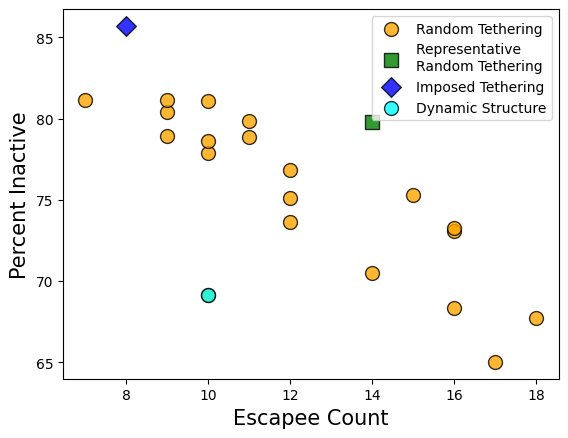

In [15]:
df_multirun=pd.read_csv("multirun_data.csv",sep=',')
n1=round(df_multirun[df_multirun['Run_ID']>0]['Escapee_Count'].mean(),2)
n2=round(df_multirun[df_multirun['Run_ID']>0]['Escapee_Count'].median(),2)
print(f'escapee count: mean={n1}, median= {n2}')
n1=round(df_multirun[df_multirun['Run_ID']>0]['Percent_Inactive'].mean(),2)
n2=round(df_multirun[df_multirun['Run_ID']>0]['Percent_Inactive'].median(),2)
print(f'percent inactive: mean={n1}, median= {n2}')
plt.scatter(df_multirun[~df_multirun['Run_ID'].isin([12,-1])]['Escapee_Count'].values\
            ,df_multirun[~df_multirun['Run_ID'].isin([12,-1])]['Percent_Inactive'].values,\
                edgecolors='k',alpha=0.8,c='orange',s=100,label='Random Tethering')
plt.scatter(df_multirun[df_multirun['Run_ID'].isin([12])]['Escapee_Count'].values\
            ,df_multirun[df_multirun['Run_ID'].isin([12])]['Percent_Inactive'].values,\
                edgecolors='k',alpha=0.8,c='green',s=100,label='Representative \nRandom Tethering',marker='s')
plt.scatter(df_multirun['Escapee_Count'].values[-1]\
            ,df_multirun['Percent_Inactive'].values[-1],\
            edgecolors='k',alpha=0.8,c='blue',s=100,label='Imposed Tethering',marker='D')
plt.scatter(df_multirun['Escapee_Count'].values[-2]\
            ,df_multirun['Percent_Inactive'].values[-2],\
            edgecolors='k',alpha=0.8,c='cyan',s=100,label='Dynamic Structure',marker='o')
plt.xlabel('Escapee Count',size=15)
plt.ylabel('Percent Inactive',size=15)
plt.legend()
plt.savefig('plot_multirun.svg',dpi=300)
plt.savefig('plot_multirun.png',dpi=300)
plt.show()

## Radial Distribution of escapee regions

### Experiment

In [45]:
def radial_dist_experiment():
    file_path1=f'data/chrom_str.dat'
    dr=0.5
    x_cords=pd.read_csv(file_path1,sep='\s+',header=None).iloc[:,0].values
    y_cords=pd.read_csv(file_path1,sep='\s+',header=None).iloc[:,1].values
    z_cords=pd.read_csv(file_path1,sep='\s+',header=None).iloc[:,2].values
    x_cen=(np.max(x_cords)+np.min(x_cords))*dr
    y_cen=(np.max(y_cords)+np.min(y_cords))*dr
    z_cen=(np.max(z_cords)+np.min(z_cords))*dr
    xi_state=np.zeros(str_len)
    df=pd.read_csv("data/XI_DATA_MOUSE_Backup.csv",header=0,index_col=None,na_filter=True)
    p_c=0.1
    for i in df.index:
        p=round(df['expression_probability'][i],1)
        if p > p_c:
            i_start=int((int(df['Location_start'][i])/(n_tot))*str_len)
            i_end=int((int(df['Location_end'][i])/(n_tot))*str_len)
            xi_state[i_start:i_end]=1
    #-----------------
    s='';n_escape=0
    for i in range(20000):
        if xi_state[i]>0:
            dist=np.sqrt((x_cords[i]-x_cen)**2+(y_cords[i]-y_cen)**2+(z_cords[i]-z_cen)**2)
            s+=f'{dist}\n'
            n_escape+=1
    print(s,file=(open('rad_dist_esc_exp.csv','w')))   
radial_dist_experiment()

### Simulation

In [46]:
def radial_dist(time,t_wri,run_id=12):
    if time!=0:
        file_path=f'data/multi_run_mouse/run_{"%02d" % run_id}/fort.{200+int(time/t_wri)}'
    else:
        file_path=f'data/multi_run_mouse/run_{"%02d" % run_id}/fort.201'
    file_path1=f'data/chrom_str.dat'
    dr=0.5
    x_cords=pd.read_csv(file_path1,sep='\s+',header=None).iloc[:,0].values
    y_cords=pd.read_csv(file_path1,sep='\s+',header=None).iloc[:,1].values
    z_cords=pd.read_csv(file_path1,sep='\s+',header=None).iloc[:,2].values
    x_cen=(np.max(x_cords)+np.min(x_cords))*dr
    y_cen=(np.max(y_cords)+np.min(y_cords))*dr
    z_cen=(np.max(z_cords)+np.min(z_cords))*dr
    sim_result=pd.read_csv(file_path,sep='\s+',header=None).iloc[:,3]
    tube_points=min(sim_result.value_counts())
    sim_result_20k=sim_result.values[::tube_points]
    sim_result_20k=np.insert(sim_result_20k,0,sim_result_20k[0])
    sim_result_20k=np.insert(sim_result_20k,-1,sim_result_20k[-1]*np.ones(2))
    #-----------------
    s='';n_escape=0
    for i in range(20000):
        dist=np.sqrt((x_cords[i]-x_cen)**2+(y_cords[i]-y_cen)**2+(z_cords[i]-z_cen)**2)
        if time!=0:
            if sim_result_20k[i]<1:
                s+=f'{dist}\n'
                n_escape+=1
        else:
            s+=f'{dist}\n'
            n_escape+=1
    print(s,file=(open('rad_dist_esc_sim.csv','w')))   
radial_dist(500,25,12)

### KDE Plot 1

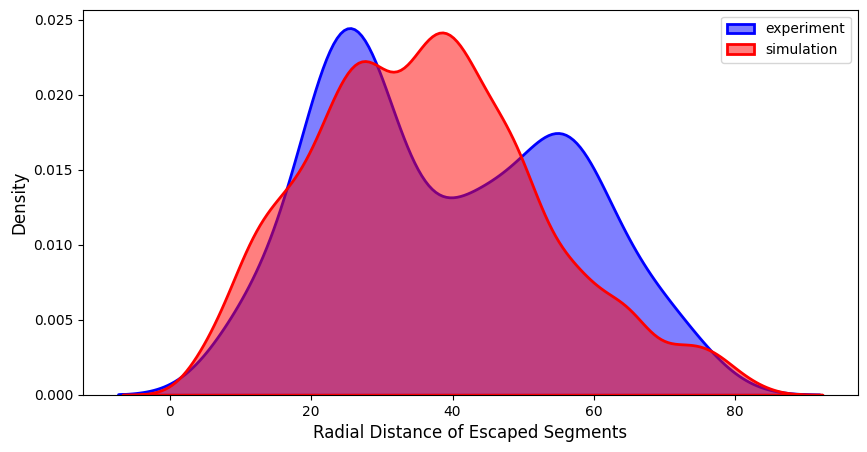

In [47]:
dat_1=pd.read_csv('rad_dist_esc_exp.csv',header=None).iloc[:,0].values
dat_2=pd.read_csv('rad_dist_esc_sim.csv',header=None).iloc[:,0].values

fig=plt.subplot()
colors=sns.color_palette('crest')
sns.kdeplot(dat_1,color='blue',alpha=.5, linewidth=2,ax=fig,fill=True,common_norm=False,label='experiment')
sns.kdeplot(dat_2,color='red',alpha=.5, linewidth=2,ax=fig,fill=True,common_norm=False,label='simulation')
fig.set_xlabel('Radial Distance of Escaped Segments',size=12)
fig.set_ylabel('Density',size=12)
plt.legend()
plt.savefig('kde_plot_esc.png',dpi=300)
plt.show()

## Radial Distribution of silenced regions

### Experiment

In [49]:
def radial_dist_experiment():
    file_path1=f'data/chrom_str.dat'
    dr=0.5
    x_cords=pd.read_csv(file_path1,sep='\s+',header=None).iloc[:,0].values
    y_cords=pd.read_csv(file_path1,sep='\s+',header=None).iloc[:,1].values
    z_cords=pd.read_csv(file_path1,sep='\s+',header=None).iloc[:,2].values
    x_cen=(np.max(x_cords)+np.min(x_cords))*dr
    y_cen=(np.max(y_cords)+np.min(y_cords))*dr
    z_cen=(np.max(z_cords)+np.min(z_cords))*dr
    xi_state=np.zeros(str_len)
    df=pd.read_csv("data/XI_DATA_MOUSE_Backup.csv",header=0,index_col=None,na_filter=True)
    p_c=0.1
    for i in df.index:
        p=round(df['expression_probability'][i],1)
        if p > p_c:
            i_start=int((int(df['Location_start'][i])/(n_tot))*str_len)
            i_end=int((int(df['Location_end'][i])/(n_tot))*str_len)
            xi_state[i_start:i_end]=1
    #-----------------
    s='';n_escape=0
    for i in range(20000):
        if xi_state[i]==0:
            dist=np.sqrt((x_cords[i]-x_cen)**2+(y_cords[i]-y_cen)**2+(z_cords[i]-z_cen)**2)
            s+=f'{dist}\n'
            n_escape+=1
    print(s,file=(open('rad_dist_sil_exp.csv','w')))   
radial_dist_experiment()

### Simulation

In [50]:
def radial_dist(time,t_wri,run_id):
    if time!=0:
        file_path=f'data/multi_run_mouse/run_{"%02d" % run_id}/fort.{200+int(time/t_wri)}'
    else:
        file_path=f'data/multi_run_mouse/run_{"%02d" % run_id}/fort.201'
    file_path1=f'data/chrom_str.dat'
    dr=0.5
    x_cords=pd.read_csv(file_path1,sep='\s+',header=None).iloc[:,0].values
    y_cords=pd.read_csv(file_path1,sep='\s+',header=None).iloc[:,1].values
    z_cords=pd.read_csv(file_path1,sep='\s+',header=None).iloc[:,2].values
    x_cen=(np.max(x_cords)+np.min(x_cords))*dr
    y_cen=(np.max(y_cords)+np.min(y_cords))*dr
    z_cen=(np.max(z_cords)+np.min(z_cords))*dr
    sim_result=pd.read_csv(file_path,sep='\s+',header=None).iloc[:,3]
    tube_points=min(sim_result.value_counts())
    sim_result_20k=sim_result.values[::tube_points]
    sim_result_20k=np.insert(sim_result_20k,0,sim_result_20k[0])
    sim_result_20k=np.insert(sim_result_20k,-1,sim_result_20k[-1]*np.ones(2))
    #-----------------
    s='';n_escape=0
    for i in range(20000):
        dist=np.sqrt((x_cords[i]-x_cen)**2+(y_cords[i]-y_cen)**2+(z_cords[i]-z_cen)**2)
        if time!=0:
            if sim_result_20k[i]>1:
                s+=f'{dist}\n'
                n_escape+=1
        else:
            s+=f'{dist}\n'
            n_escape+=1
    print(s,file=(open('rad_dist_sil_sim.csv','w')))   
radial_dist(500,25,12)

### KDE Plot

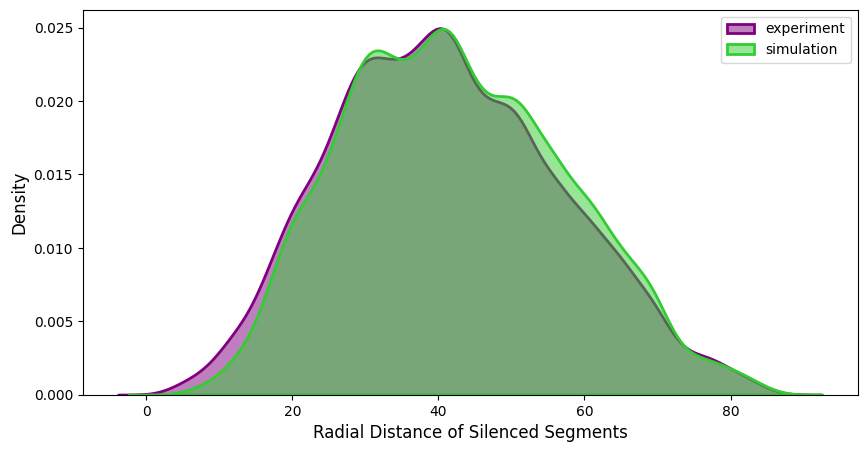

In [52]:
dat_1=pd.read_csv('rad_dist_sil_exp.csv',header=None).iloc[:,0].values
dat_2=pd.read_csv('rad_dist_sil_sim.csv',header=None).iloc[:,0].values

fig=plt.subplot()
colors=sns.color_palette('crest')
sns.kdeplot(dat_1,color='purple',alpha=.5, linewidth=2,ax=fig,fill=True,common_norm=False,label='experiment')
sns.kdeplot(dat_2,color='limegreen',alpha=.5, linewidth=2,ax=fig,fill=True,common_norm=False,label='simulation')
fig.set_xlabel('Radial Distance of Silenced Segments',size=12)
fig.set_ylabel('Density',size=12)
plt.legend()
plt.savefig('kde_plot_sil.png',dpi=300)
plt.show()

### KDE Plot 2

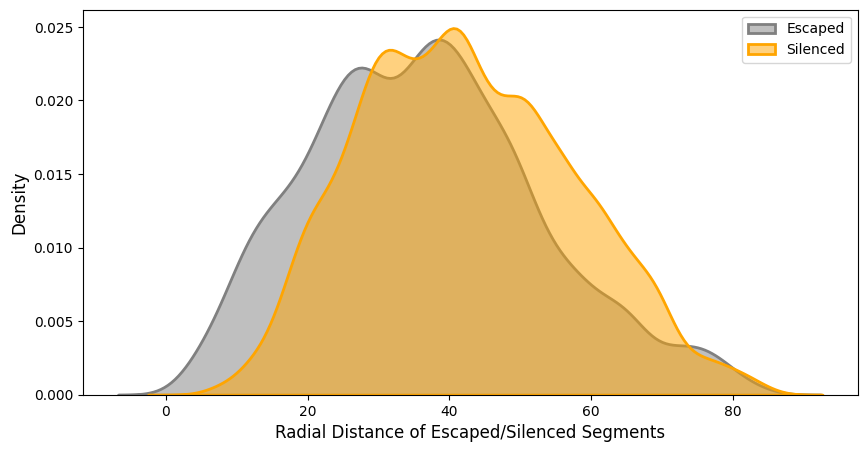

In [53]:
dat_1=pd.read_csv('rad_dist_esc_sim.csv',header=None).iloc[:,0].values
dat_2=pd.read_csv('rad_dist_sil_sim.csv',header=None).iloc[:,0].values

fig=plt.subplot()
colors=sns.color_palette('crest')
sns.kdeplot(dat_1,color='gray',alpha=.5, linewidth=2,ax=fig,fill=True,common_norm=False,label='Escaped')
sns.kdeplot(dat_2,color='orange',alpha=.5, linewidth=2,ax=fig,fill=True,common_norm=False,label='Silenced')
fig.set_xlabel('Radial Distance of Escaped/Silenced Segments',size=12)
fig.set_ylabel('Density',size=12)
plt.legend()
plt.savefig('kde_plot_esc_sil_sim.png',dpi=300)
plt.show()

# Visualization of captured genes

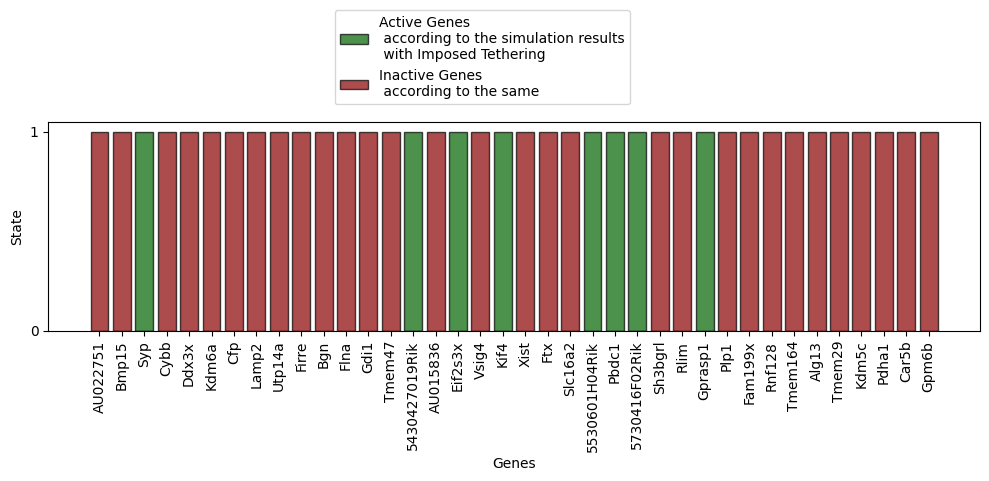

In [54]:
df_sorted=df_data_ana.sort_values(by='start')
df_sorted=df_sorted[df_sorted['state_exp']!=0]
df_data_ana.to_csv(f"exp_sim_match_{species}.csv")
plt.rcParams["figure.figsize"] = (10,5)
plt.bar(df_sorted['genes'],1.0*df_sorted['state_sim'],color='darkgreen',label='Active Genes \n according to the simulation results\n with Imposed Tethering',edgecolor='black',alpha=0.7)
plt.bar(df_sorted['genes'],(df_sorted['state_sim']-1)*-1,color='darkred',label='Inactive Genes\n according to the same',edgecolor='black',alpha=0.7)
#plt.stem(df_sorted['genes'],df_sorted['state_exp'],markerfmt='C2',basefmt='k--',label="EXP")
plt.legend(bbox_to_anchor=(0.3, 1.05), loc='lower left')
plt.xlabel('Genes')
plt.ylabel('State')
# plt.ylim([0,1.5])
plt.xticks(rotation=90,ha='center') #df_sorted['start'].values,df_sorted['genes']
plt.yticks([0,1]) #df_sorted['start'].values,df_sorted['genes']
plt.tight_layout()
plt.savefig('imposed_teth_3d.png',dpi=300)
plt.show()

## Experimental Inactive Genes

In [56]:
def inactive_gene_analysis(time,t_wri,run_id,mode):
    df_exp_res=pd.read_csv('data/inactivated_genes.csv',sep=',')
    if mode.lower()=='random':
        file_path=f'data/multi_run_mouse/run_{"%02d" % run_id}/fort.{200+int(time/t_wri)}'
    if mode.lower()=='imposed':
        file_path='data/imposed_teth_mouse/fort.220'
    sim_result=pd.read_csv(file_path,sep='\s+',header=None).iloc[:,3]
    tube_points=min(sim_result.value_counts())
    sim_result_20k=sim_result.values[::tube_points]
    sim_result_20k=np.insert(sim_result_20k,0,sim_result_20k[0])
    sim_result_20k=np.insert(sim_result_20k,-1,sim_result_20k[-1]*np.ones(2))
    #-----------------
    sim_result_binary=np.ones(20000)
    for i in range(20000):
        if sim_result_20k[i] <1:
            sim_result_binary[i]=1
        else:
            sim_result_binary[i]=0
    #-----------------
    n=0;n_tot=0
    for i in df_exp_res['polymer_seg'].values:
        n_tot+=1
        if sim_result_binary[i]==0:
            n+=1
    print(f'total inactive genes--> {n_tot}\ncaptured inactive genes in simulation ({mode} teth)--> {n}')
    print(f'Time={time}\nfile_path= {file_path}')
inactive_gene_analysis(time=500,t_wri=25,run_id=12,mode='random')

total inactive genes--> 383
captured inactive genes in simulation (random teth)--> 290
Time=500
file_path= data/multi_run_mouse/run_12/fort.220


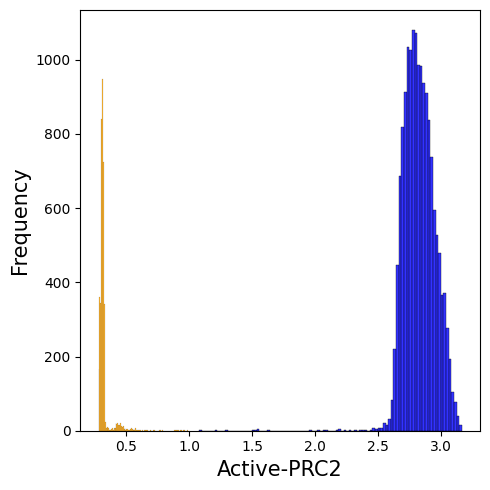

In [57]:
file_path=f'data/multi_run_mouse/run_12/fort.220'
sim_result=pd.read_csv(file_path,sep='\s+',header=None).iloc[:,3]
tube_points=min(sim_result.value_counts())
sim_result_20k=sim_result.values[::tube_points]
sim_result_20k=np.insert(sim_result_20k,0,sim_result_20k[0])
sim_result_20k=np.insert(sim_result_20k,-1,sim_result_20k[-1]*np.ones(2))
sim_result_20k_yellow=[i for i in sim_result_20k if i < 1]
sim_result_20k_blue=[i for i in sim_result_20k if i > 1]
fig,ax=plt.subplots(1,1,figsize=(5,5))
sns.histplot(sim_result_20k_blue,ax=ax,alpha=0.8,color='blue',bins=100)
sns.histplot(sim_result_20k_yellow,ax=ax,alpha=0.8,color='orange',bins=100)
ax.set_xlabel('Active-PRC2',size=15)
ax.set_ylabel('Frequency',size=15)
plt.tight_layout()
plt.savefig('sim_hist.svg',dpi=300)
plt.savefig('sim_hist.png',dpi=300)
plt.show()

## Generate tube from simulation result

In [58]:
def compute_tangent_vector(point, trajectory):
    index = np.where((trajectory == point).all(axis=1))[0][0]
    if index == 0:
        tangent = trajectory[1] - trajectory[0]
    elif index == len(trajectory) - 1:
        tangent = trajectory[-1] - trajectory[-2]
    else:
        tangent = trajectory[index + 1] - trajectory[index - 1]
    return tangent / np.linalg.norm(tangent)

def compute_normal_vector(tangent):
    v = np.array([1, 0, 0]) if np.abs(tangent[0]) > 1e-6 else np.array([0, 1, 0])
    normal = np.cross(tangent, v)
    return normal / np.linalg.norm(normal)

def compute_binormal_vector(tangent, normal):
    return np.cross(tangent, normal)

def generate_tube_from_trajectory(trajectory, radius=0.1, num_segments=20,rad_guide=[]):
    tube_whole=[];radius_eff=radius
    for i in range(len(trajectory)):
        point = trajectory[i]
        tangent = compute_tangent_vector(point, trajectory)
        normal = compute_normal_vector(tangent)
        binormal = compute_binormal_vector(tangent, normal)

        # Create points for the tube at this point in the trajectory
        u = np.linspace(0, 2 * np.pi, num_segments)
        tube_points = []
        if len(rad_guide) != 0:
            if rad_guide[i]==1:
                radius_eff=2*radius
            else:
                radius_eff=radius
        for angle in u:
            tube_point = point + radius_eff * (np.cos(angle) * normal + np.sin(angle) * binormal)
            tube_points.append(tube_point)
        tube_points = np.array(tube_points)
        tube_whole.append(tube_points)
    return tube_whole

In [59]:
#-----------------------------------------
## xci
#-----------------------------------------
# file_path=f'/home/spaul18/ongoing-work/xci/data/3-xci-3d/3-combined/delta_1.12/mouse/fort.220'
file_path=f'data/multi_run_mouse/run_12/fort.204'
sim_result=pd.read_csv(file_path,sep='\s+',header=None).iloc[:,3]
tube_points=min(sim_result.value_counts())
sim_result_20k=sim_result.values[::tube_points]
sim_result_20k=np.insert(sim_result_20k,0,sim_result_20k[0])
sim_result_20k=np.insert(sim_result_20k,-1,sim_result_20k[-1]*np.ones(2))
tube_radius=0.07
tube=generate_tube_from_trajectory(chrom_str,num_segments=6,radius=tube_radius,)
out_str=""
for i in range(len(chrom_str)):
    for j in range(len(tube[0][:,0])):
        out_str+=f"{round(tube[i][j,0],3)} {round(tube[i][j,1],3)} {round(tube[i][j,2],3)} {sim_result_20k[i]}\n"
    out_str+="\n"
with open('tube_output_xci.dat', 'w') as file:
    file.write(out_str)

In [60]:
polar=90
azi=230
os.system("head -n -3 gp_xci.sh > tmp.txt && mv tmp.txt gp_xci.sh")
os.system("echo set cbrange [0:0.8] >> gp_xci.sh")
os.system(fr"echo set view {polar},{azi} >> gp_xci.sh && echo sp \"tube_output_xci.dat\" u 1:2:3:4 w pm3d >> gp_xci.sh")
os.system("gnuplot gp_xci.sh > /dev/null");  # filename: "output-xci.png"

## Experimental data plot 3D

In [61]:
# Usage
tube_radius=0.07
tube=generate_tube_from_trajectory(chrom_str,num_segments=6,radius=tube_radius)
out_str=""
for i in range(len(chrom_str)):
    for j in range(len(tube[0][:,0])):
        out_str+=f"{round(tube[i][j,0],3)} {round(tube[i][j,1],3)} {round(tube[i][j,2],3)} {xi_state[i]}\n"
    out_str+="\n"
with open('tube_output_xci_e.dat', 'w') as file:
    file.write(out_str)
os.system("gnuplot gp_xci_e.sh > /dev/null") # file name output-xci-exp.png

1

## ============================================

# Tethering plot 3D

In [62]:
#-----------------------------------------
# tethering 
#-----------------------------------------
file_path=f'data/multi_run_mouse/run_12/fort.600'
sim_result=pd.read_csv(file_path,sep='\s+',header=None).iloc[:,0].values
tube_radius=0.07
nn=5
for i in range(nn,len(sim_result)-nn):
    if sim_result[i]==1:
        sim_result[(i-nn):(i+1)]=1
tube=generate_tube_from_trajectory(chrom_str,num_segments=6,radius=tube_radius,rad_guide=sim_result)
out_str=""
for i in range(len(chrom_str)):
    for j in range(len(tube[0][:,0])):
        out_str+=f"{round(tube[i][j,0],3)} {round(tube[i][j,1],3)} {round(tube[i][j,2],3)} {sim_result[i]}\n"
    out_str+="\n"
with open('tube_output_teth.dat', 'w') as file:
    file.write(out_str)

os.system("gnuplot gp_teth.sh > /dev/null");# file name: output-teth.png